In [1]:
import pandas as pd
import glob
import os
import re
import numpy as np
import pyarrow

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

In [2]:
#gather all absolute file paths in raw data folder and place them in a list
def get_files():
    raw_data_path = os.path.abspath(os.path.join(os.getcwd(),".."))
    pattern = os.path.join(raw_data_path,"data","raw","*.xlsx")
    file_lst = glob.glob(pattern)
    return file_lst

In [3]:
#clean and filter data to acceptable parameters
def clean_filter(quarter_df_lst):
    #strip and force lowercase on all, force single "_" between words 
    for q in quarter_df_lst:
        q.columns = q.columns.str.lower()
        q.columns = q.columns.str.strip()
        q.columns = q.columns.str.replace('\\s+', '_', regex=True)
    #filter out any sheets with less than 5 rows
    length_check = [v for v in quarter_df_lst if len(v) > 5]
    #filter out sheets without expected cols
    required_cols = {"start","details","status_text","booking_source","player_count","tee_sheet","date_cancelled"}
    col_check = [v for v in length_check if required_cols.issubset(set(v.columns))]
    #filter out sheets with more than 10% NA values on the start time
    valid_start_time = [v for v in col_check if v["start"].isna().mean() < 0.10]
    final = valid_start_time
    return final
    
#for each file, collect each tab into a dict w/ tab name as key, df of data as value. concat all tabs into a full year df
year_dfs = []
file_lst = get_files()
for file in file_lst:
    quarter_dict = pd.read_excel(file,sheet_name=None)
    quarters = list(quarter_dict.values())
    quarters = clean_filter(quarters)
    if quarters:
        year = pd.concat(quarters)
        year_dfs.append(year)
    else: 
        print(f"'{os.path.basename(file)}': no valid data")

#concat all year dfs into one master df
master_raw = pd.concat(year_dfs,ignore_index=True)


In [4]:
#print(master_raw.dtypes)

In [5]:
#basic cleaning, convert start to datetime, drop booking_source (provides no meaningful input here), rename start to tee_time for clarity
#convert cancellation time to datetime
master_df = master_raw.copy()
master_df["start"] = pd.to_datetime(master_df["start"])
master_df.drop(columns=["booking_source"],inplace=True)
master_df.rename(columns={"start":"tee_time"},inplace=True)
master_df["date_cancelled"] = pd.to_datetime(master_df["date_cancelled"],errors="coerce")


In [6]:
# #evaluating unique values and counts to see if it makes sense apply some further cleaning to allow more analysis
# for col in master_df.columns:
#     display(master_df[col].value_counts(dropna=False))
#     display(master_df.loc[master_df[col].isna()])

In [7]:
#clean time, date, and cost out of details using regex,drop any rows that extract time data to nan
master_df[["book_hr","book_min","am_pm","book_month","book_day","cost_per_group"]] = master_df["details"].str.extract(r"@\s(\d{1,2}):(\d{2})(am|pm|AM|PM|Am|Pm)\s(\d{1,2})\/(\d{1,2})(?:.*?\$(\d+\.\d{2}))?")
failed_extract_count = master_df[["book_hr","book_min","am_pm","book_month","book_day"]].isna().any(axis=1).sum()
master_df.dropna(subset=["book_hr","book_min","am_pm","book_month","book_day"],inplace=True)
master_df[["book_hr","book_min","book_month","book_day"]] = master_df[["book_hr","book_min","book_month","book_day"]].astype(int)
master_df["cost_per_group"] = pd.to_numeric(master_df["cost_per_group"], errors="coerce")

#reformat book time to 24hr to enable cleaning
master_df.loc[(master_df["am_pm"] == "pm")&(master_df["book_hr"] != 12), "book_hr"] = master_df.loc[(master_df["am_pm"] == "pm")&(master_df["book_hr"] != 12), "book_hr"]+12
master_df.loc[(master_df["book_hr"] == 12) & (master_df["am_pm"] == "am"), "book_hr"] = 0

# pull year from start, adjust booking time to previous year if booking in dec and tee time in jan
master_df["book_yr"] = master_df["tee_time"].dt.year
master_df.loc[(master_df["tee_time"].dt.month == 1)&(master_df["book_month"] == 12),"book_yr"] = master_df.loc[(master_df["tee_time"].dt.month == 1)&(master_df["book_month"] == 12),"book_yr"]-1

#check that date components are within valid ranges
date_check = {
    "months": (master_df["book_month"].between(1, 12)).all(),
    "days": (master_df["book_day"].between(1, 31)).all(),
    "hrs": (master_df["book_hr"].between(0, 23)).all(),
    "mins": (master_df["book_min"].between(0, 59)).all(),
}

#convert cleaned data to datetime
master_df["booking_time"] = pd.to_datetime(
    {
        "year": master_df["book_yr"],
        "month": master_df["book_month"],
        "day": master_df["book_day"],
        "hour": master_df["book_hr"],
        "minute": master_df["book_min"],
    },
    errors="coerce",
)
book_time_failures_count = master_df["booking_time"].isna().sum()
bad_book_time = master_df.index[master_df["booking_time"].isna()]
master_df.drop(bad_book_time,inplace=True)

# #drop helper date columns to clean up df, reorganize cols
master_df.drop(columns=["book_hr","book_min","am_pm","book_month","book_day", "book_yr"],inplace=True)
master_df = master_df[['tee_time', 'details', 'booking_time', 'status_text', 'player_count', 'tee_sheet',
       'date_cancelled', 'cost_per_group']]

#drop any rows where booking time occurs after tee time. No clear explanation for this upon analysis so it will be treated as noise (~1 row impacted)
bad_time_order = master_df.index[master_df["booking_time"] > master_df["tee_time"]]
master_df.drop(bad_time_order,inplace=True)


In [8]:
#details col extraction QA checks:
print("Details column data extraction QA checks:")
print(f"\t{failed_extract_count} rows dropped due to invalid time data regex results")
for k,v in date_check.items():
    if v:
        print(f"\tall {k} in valid ranges")
    else:
        print(f"\t{k} has invalid values")
print(f"\t{book_time_failures_count} rows dropped due to failed booking time datetime conversion")

Details column data extraction QA checks:
	4 rows dropped due to invalid time data regex results
	all months in valid ranges
	all days in valid ranges
	all hrs in valid ranges
	all mins in valid ranges
	0 rows dropped due to failed booking time datetime conversion


In [9]:
# #status_text investigation and cleaning
# for val in master_df["status_text"].unique():
#     display(master_df.loc[master_df["status_text"] == val])
# display(master_df.loc[master_df["status_text"].isna()])

#Adjust and collapse status_text values based on invesigation
#collapse "checked in" and "teed off" to "played"
df_size_start = len(master_df)
master_df.loc[(master_df["status_text"] == "checked in")|(master_df["status_text"] == "teed off"),"status_text"] = "played"

#reword deleted to cancelled for clarity 
master_df.loc[master_df["status_text"] == "deleted","status_text"] = "cancelled"

#coerce NAN to unknown
master_df.loc[master_df["status_text"].isna(),"status_text"] = "unknown"

#flag cancelled rows w/ no cancellation time
master_df["invalid_cancellation"] = (master_df["status_text"]=="cancelled")&(master_df["date_cancelled"].isna())

#QA helper values
df_size_end = len(master_df)
played_cancel_time_count = ((master_df["status_text"]=="played")&(master_df["date_cancelled"].notna())).sum()
cancel_no_time_count = ((master_df["status_text"]=="cancelled")&(master_df["date_cancelled"].isna())).sum()
#display(master_df.loc[(master_df["status_text"]=="cancelled")&(master_df["date_cancelled"].isna())])

In [10]:
#status_text col extraction QA checks:
print("status_text column data extraction QA checks:")
if df_size_start == df_size_end:
    print(f"\tdataframe size remained constant")
else:
    print(f"\tdataframe size did not remain constant")
print(f"\t{played_cancel_time_count} rows marked as played but have a cancellation time listed")
print(f"\t{cancel_no_time_count} rows marked as cancelled but have no cancellation time listed")

status_text column data extraction QA checks:
	dataframe size remained constant
	0 rows marked as played but have a cancellation time listed
	800 rows marked as cancelled but have no cancellation time listed


In [11]:
#player_count cleaning
# invalid_player_counts = master_df.loc[(master_df["player_count"]<1)|(master_df["player_count"]>4)].sort_values(by="player_count")
# display(invalid_player_counts)
#extract player counts from details column and count mismatches between native player_count data
master_df["player_count_regex"] = master_df["details"].str.extract(r"([1-4])\s+Players?").astype(float)
discrepant_row_init_pct = (master_df["player_count"] != master_df["player_count_regex"]).mean()

#create new col to capture reconsiled value and correct bad values in player_count with regex results
master_df["player_count_final"] = master_df["player_count"]
master_df.loc[(master_df["player_count_final"]!=master_df["player_count_regex"])&(master_df["player_count_regex"].notna()),"player_count_final"] = master_df["player_count_regex"]

#recount rows with discrepancies after cleaning and drop them since no valid data can be extracted to correct them
discrepant_row_fin_pct = ((master_df["player_count_final"]<1)|(master_df["player_count_final"]>4)|(master_df["player_count_final"].isna())).mean()
bad_row_index = master_df.loc[(master_df["player_count_final"]<1)|(master_df["player_count_final"]>4)|(master_df["player_count_final"].isna())].index
master_df.drop(bad_row_index,inplace=True)

#drop player_count (exists in raw df still) and regex helper column to clean up df
master_df.drop(columns=["player_count","player_count_regex"],inplace=True)


In [12]:
#player_count QA
print("player_count column data extraction QA checks:")
print(f"\t{discrepant_row_init_pct:.2%} of rows were corrected after finding incorrect player counts in player_count")
print(f"\t{discrepant_row_fin_pct:.4%} of rows were dropped after finding incorrect player counts after cleaning")

player_count column data extraction QA checks:
	12.48% of rows were corrected after finding incorrect player counts in player_count
	0.0003% of rows were dropped after finding incorrect player counts after cleaning


In [13]:
#clean course out of tee_sheet and count rows where course not found
master_df["course"] = master_df["tee_sheet"].str.extract(r"\b(black|red|blue|green|yellow)\b",flags = re.IGNORECASE, expand = True)
bad_course_pct = (master_df["course"].isna()).mean()
master_df.loc[master_df["course"].isna(),"course"] = "unknown"


#clean round length (9 or 18 holes) out of tee_sheet. Assume any non-9 hole round is 18 because 18 is never explicitly stated in the data
master_df["round_length"] = master_df["tee_sheet"].str.extract(r"(?:\b(9)\s*holes?\b)",flags = re.IGNORECASE, expand = True)
master_df.loc[master_df["round_length"].isna(),"round_length"] = 18
master_df["round_length"] = master_df["round_length"].astype(int)
eighteen_hole_pct = bad_course_count = (master_df["round_length"]==18).mean()

#categorize weekend/weekday and time of day to ensure data is not lost when dropping tee_sheet
master_df["week_day"] = master_df["tee_time"].dt.weekday
master_df["time_of_week"] = np.where(master_df["week_day"]>=5,"weekend","weekday")

hours = master_df["tee_time"].dt.hour

master_df["time_of_day"] = pd.cut(
    hours,
    bins=[-1, 10, 15, 23],
    labels=["morning", "midday", "evening"]
)

#add flag for invalid tee times after 8PM and before 5AM
master_df["invalid_tee_time"] = (master_df["tee_time"].dt.hour<5)|(master_df["tee_time"].dt.hour>19)
bad_tee_time_pct = master_df["invalid_tee_time"].mean()

#drop tee_sheet after data extraction
master_df.drop(columns=["tee_sheet","week_day"],inplace=True)

In [14]:
#tee_sheet QA
print("tee_sheet column data extraction QA checks:")
print(f"\t{bad_course_pct:.2%} of rows do not have a course assigned in the raw data and were set to course 'unknown'")
print(f"\t{eighteen_hole_pct:.4%} of rows were assumed to be 18 hole rounds after extracting 9 hole rounds via regex")
print(f"\t{bad_tee_time_pct:.2%} of rows contain invalid tee times before 5AM or after 8PM")
print(f"\tCrosstab below to confirm bin functionality")
pd.crosstab(
    master_df["time_of_day"],
    master_df["tee_time"].dt.hour
)

tee_sheet column data extraction QA checks:
	9.71% of rows do not have a course assigned in the raw data and were set to course 'unknown'
	69.8492% of rows were assumed to be 18 hole rounds after extracting 9 hole rounds via regex
	0.01% of rows contain invalid tee times before 5AM or after 8PM
	Crosstab below to confirm bin functionality


tee_time,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21
time_of_day,,,,,,,,,,,,,,,,,
morning,265,32067,42804,51739,54622,48295,0,0,0,0,0,0,0,0,0,0,0
midday,0,0,0,0,0,0,59375,69425,59323,63780,57265,0,0,0,0,0,0
evening,0,0,0,0,0,0,0,0,0,0,0,43149,25243,8511,103,46,1


In [15]:
#final cleanup and export
master_df = master_df[['tee_time', 'booking_time', 'status_text', 'date_cancelled','time_of_week', 'time_of_day','player_count_final','course',
                       'round_length','cost_per_group', 'invalid_cancellation', 'invalid_tee_time']]
master_df["time_of_week"] = master_df["time_of_week"].astype("category")
master_df["status_text"] = master_df["status_text"].astype("category")
master_df["time_of_day"] = pd.Categorical(master_df["time_of_day"],categories=["morning", "midday", "evening"],ordered=True)
display(master_df)
display(master_df.dtypes)

# #NOTE - running this cell will overwrite existing cleaned datasets in the directory
# #define path and export parquet file
# processed_dir = os.path.join(os.getcwd(), "..", "data", "cleaned")
# os.makedirs(processed_dir, exist_ok=True)
# parquet_path = os.path.join(processed_dir,"bethpage_bookings_clean.parquet")
# master_df.to_parquet(parquet_path,index=False)

# #take a random sample of 50k rows to make a sample CSV for lighter review, no analysis will be done on this documentation purposes only
# sample_df = sample_df = master_df.sample(n=50_000, random_state=42)
# processed_dir = os.path.join(os.getcwd(), "..", "data", "cleaned")
# os.makedirs(processed_dir, exist_ok=True)
# csv_path = os.path.join(processed_dir,"bethpage_bookings_clean_sample.csv")
# sample_df.to_csv(csv_path,index=False)

# #export quality QA
# reloaded = pd.read_parquet(parquet_path)
# assert len(reloaded) == len(master_df)
# assert reloaded.dtypes.equals(master_df.dtypes)


,tee_time,booking_time,status_text,date_cancelled,time_of_week,time_of_day,player_count_final,course,round_length,cost_per_group,invalid_cancellation,invalid_tee_time
0,2021-03-14 07:51:00,2021-03-07 19:00:00,played,NaT,weekend,morning,2,Blue,9,124.0,False,False
1,2021-03-14 07:51:00,2021-03-13 21:35:00,played,NaT,weekend,morning,1,Blue,9,31.0,False,False
2,2021-03-14 08:00:00,2021-03-13 15:32:00,played,NaT,weekend,morning,2,Blue,9,62.0,False,False
3,2021-03-14 08:27:00,2021-03-13 11:19:00,played,NaT,weekend,morning,4,Blue,9,124.0,False,False
4,2021-03-14 08:36:00,2021-03-13 17:42:00,played,NaT,weekend,morning,3,Blue,9,93.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
616027,2025-10-21 13:42:00,2025-10-14 20:00:00,unknown,NaT,weekday,midday,1,Blue,18,15.0,False,False
616028,2025-10-21 13:42:00,2025-10-15 12:32:00,unknown,NaT,weekday,midday,1,Blue,18,23.0,False,False
616029,2025-10-21 13:51:00,2025-10-14 19:02:00,unknown,NaT,weekday,midday,4,Blue,18,92.0,False,False
616030,2025-10-21 14:00:00,2025-10-14 20:55:00,cancelled,2025-10-14 21:21:01,weekday,midday,4,Blue,18,NaN,False,False


tee_time                datetime64[ns]
booking_time            datetime64[ns]
status_text                   category
date_cancelled          datetime64[ns]
time_of_week                  category
time_of_day                   category
player_count_final               int64
course                          object
round_length                     int64
cost_per_group                 float64
invalid_cancellation              bool
invalid_tee_time                  bool
dtype: object

In [16]:
# #evaluating unique values and counts to see if it makes sense apply some further cleaning to allow more analysis
# for col in master_df.columns:
#     display(master_df[col].value_counts(dropna=False))
#     display(master_df.loc[master_df[col].isna()])

<Axes: title={'center': 'status_text distribution by year'}, xlabel='Year', ylabel='Count'>

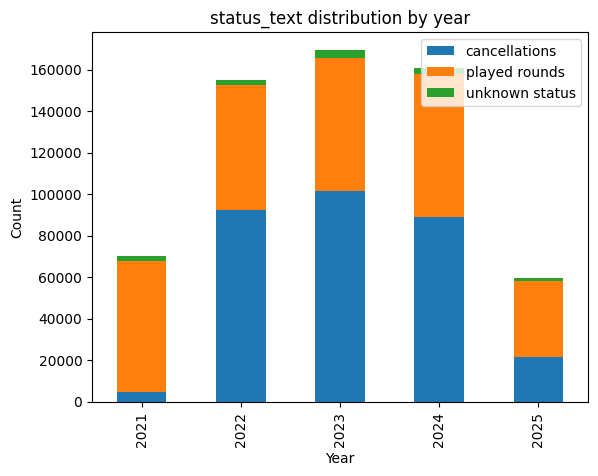

In [57]:
#quick EDA graphs for README prior to pause
valid_cancellations = master_df.loc[~master_df["invalid_cancellation"]]

rounds_by_year = valid_cancellations["tee_time"].groupby(valid_cancellations["tee_time"].dt.year).count().rename("rounds")

cancellations_by_year = valid_cancellations.loc[valid_cancellations["status_text"]=="cancelled"].groupby(
    valid_cancellations["tee_time"].dt.year)["tee_time"].count().rename("cancellations")


plays_by_year = valid_cancellations.loc[valid_cancellations["status_text"]=="played"].groupby(
    valid_cancellations["tee_time"].dt.year)["tee_time"].count().rename("played rounds")

unknown_by_year = valid_cancellations.loc[valid_cancellations["status_text"]=="unknown"].groupby(
    valid_cancellations["tee_time"].dt.year)["tee_time"].count().rename("unknown status")

status_text_dist = pd.concat([cancellations_by_year,plays_by_year,unknown_by_year],axis=1)

status_text_dist_graph = status_text_dist.plot.bar(stacked=True, title="status_text distribution by year")
status_text_dist_graph.set_xlabel('Year')
status_text_dist_graph.set_ylabel('Count')
fig = status_text_dist_graph.get_figure()
fig.savefig("status_text_dist.png", dpi=300, bbox_inches='tight')
display(status_text_dist_graph)

